# Virtual Staining: Zero-Cost Multiplexed Imaging from H&E Images

This tutorial introduces one of the advanced features of LazySlide: the ability to transform a standard H&E (Hematoxylin and Eosin) histology image into a multiplexed image with multiple predicted biomarker channels. This powerful technique enables researchers to extract rich molecular information from routine histological slides without the need for expensive immunohistochemistry or specialized staining protocols.

/home/yzheng/.local/share/uv/python/cpython-3.12.9-linux-x86_64-gnu/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)
/data-nvme0/projects/lazyslide-tutorials/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/data-nvme0/projects/lazyslide-tutorials/.venv/lib/python3.12/site-packages/wsidata/io/_wsi.py:136: UserWarning: SpatialData is not stored in the most curre

WSI: /opt/hf_cache/datasets--RendeiroLab--LazySlide-data/snapshots/9644d886889040fa10e757d912f249bbf936a979/sample.svs
Reader: openslide
Dimensions: 2967×2220 (h×w), 1 Pyramid
Pixel physical size: 0.499 MPP
SpatialData object, with associated Zarr store: /opt/hf_cache/datasets--RendeiroLab--LazySlide-data/snapshots/9644d886889040fa10e757d912f249bbf936a979/sample.zarr
├── Images
│     └── 'wsi_thumbnail': DataArray[cyx] (3, 1496, 1119)
├── Shapes
│     ├── 'annotations': GeoDataFrame shape: (3, 4) (2D shapes)
│     ├── 'dl-tissue': GeoDataFrame shape: (2, 2) (2D shapes)
│     ├── 'tiles': GeoDataFrame shape: (31, 3) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (1, 2) (2D shapes)
└── Tables
      └── 'resnet50_tiles': AnnData (31, 2048)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images), annotations (Shapes), dl-tissue (Shapes), tiles (Shapes), tissues (Shapes)
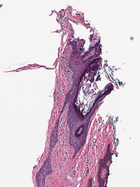

In [1]:
# Import LazySlide and load a sample whole slide image (WSI)
import lazyslide as zs

wsi = zs.datasets.sample()
wsi

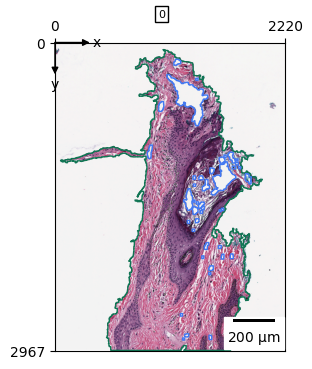

In [2]:
zs.pl.tissue(wsi)

In [4]:
zs.pp.tile_tissues(wsi, 256, stride_px=32)

# Apply virtual staining using the GigaTime model
zs.tl.virtual_stain(wsi, model="gigatime")

Output()

## Examining the Results

Let's examine our WSI object to see how the virtual staining has enhanced our data:

/data-nvme0/projects/lazyslide-tutorials/.venv/lib/python3.12/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


WSI: /opt/hf_cache/datasets--RendeiroLab--LazySlide-data/snapshots/9644d886889040fa10e757d912f249bbf936a979/sample.svs
Reader: openslide
Dimensions: 2967×2220 (h×w), 1 Pyramid
Pixel physical size: 0.499 MPP
SpatialData object, with associated Zarr store: /opt/hf_cache/datasets--RendeiroLab--LazySlide-data/snapshots/9644d886889040fa10e757d912f249bbf936a979/sample.zarr
├── Images
│     ├── 'gigatime_prediction': DataArray[cyx] (23, 2967, 2220)
│     └── 'wsi_thumbnail': DataArray[cyx] (3, 1496, 1119)
├── Shapes
│     ├── 'annotations': GeoDataFrame shape: (3, 4) (2D shapes)
│     ├── 'dl-tissue': GeoDataFrame shape: (2, 2) (2D shapes)
│     ├── 'tiles': GeoDataFrame shape: (1868, 3) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (1, 2) (2D shapes)
└── Tables
      └── 'resnet50_tiles': AnnData (31, 2048)
with coordinate systems:
    ▸ 'global', with elements:
        gigatime_prediction (Images), wsi_thumbnail (Images), annotations (Shapes), dl-tissue (Shapes), tiles (Shapes), tissues (Shapes)
with the following elements not in the Zarr store:
    ▸ gigatime_prediction (Images)
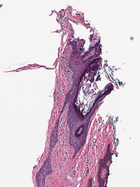

In [5]:
wsi

## Understanding Virtual Staining Output

The virtual staining process generates predicted biomarker images that are stored in the `images` slot of the WSI data object (SpatialData format). 

**ROSIE**
- The ROSIE model makes predictions at the tile level, generating a mean expression value for each biomarker within each tile
- This approach provides spatial gene expression predictions across the entire tissue section
- For higher resolution results, consider using smaller tile sizes with more overlap

To replicate the exact settings from the original ROSIE paper, use:
```python
zs.pp.tile_tissues(wsi, 128, stride_px=8)
```

**GigaTIME**

If you use GigaTIME model, it's a UNet structure model that predict the pixel level expression.

Let's explore the generated predictions:

In [6]:
# Access the virtual staining predictions stored in the images dictionary
wsi.images["gigatime_prediction"]

<xarray.DataArray 'image' (c: 23, y: 2967, x: 2220)> Size: 606MB
dask.array<array, shape=(23, 2967, 2220), dtype=float32, chunksize=(23, 1207, 1207), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U10 920B 'DAPI' 'TRITC' 'Cy5' ... 'PHH3-B' 'Transgelin'
  * y        (y) float64 24kB 0.5 1.5 2.5 3.5 ... 2.964e+03 2.966e+03 2.966e+03
  * x        (x) float64 18kB 0.5 1.5 2.5 3.5 ... 2.218e+03 2.218e+03 2.22e+03
Attributes:
    transform:  {'global': Scale (y, x)\n    [1. 1.]}

In [7]:
# Display all available biomarker channels predicted by the GigaTime model
wsi.images["gigatime_prediction"].c.data

array(['DAPI', 'TRITC', 'Cy5', 'PD-1', 'CD14', 'CD4', 'T-bet', 'CD34',
       'CD68', 'CD16', 'CD11c', 'CD138', 'CD20', 'CD3', 'CD8', 'PD-L1',
       'CK', 'Ki67', 'Tryptase', 'Actin-D', 'Caspase3-D', 'PHH3-B',
       'Transgelin'], dtype='<U10')

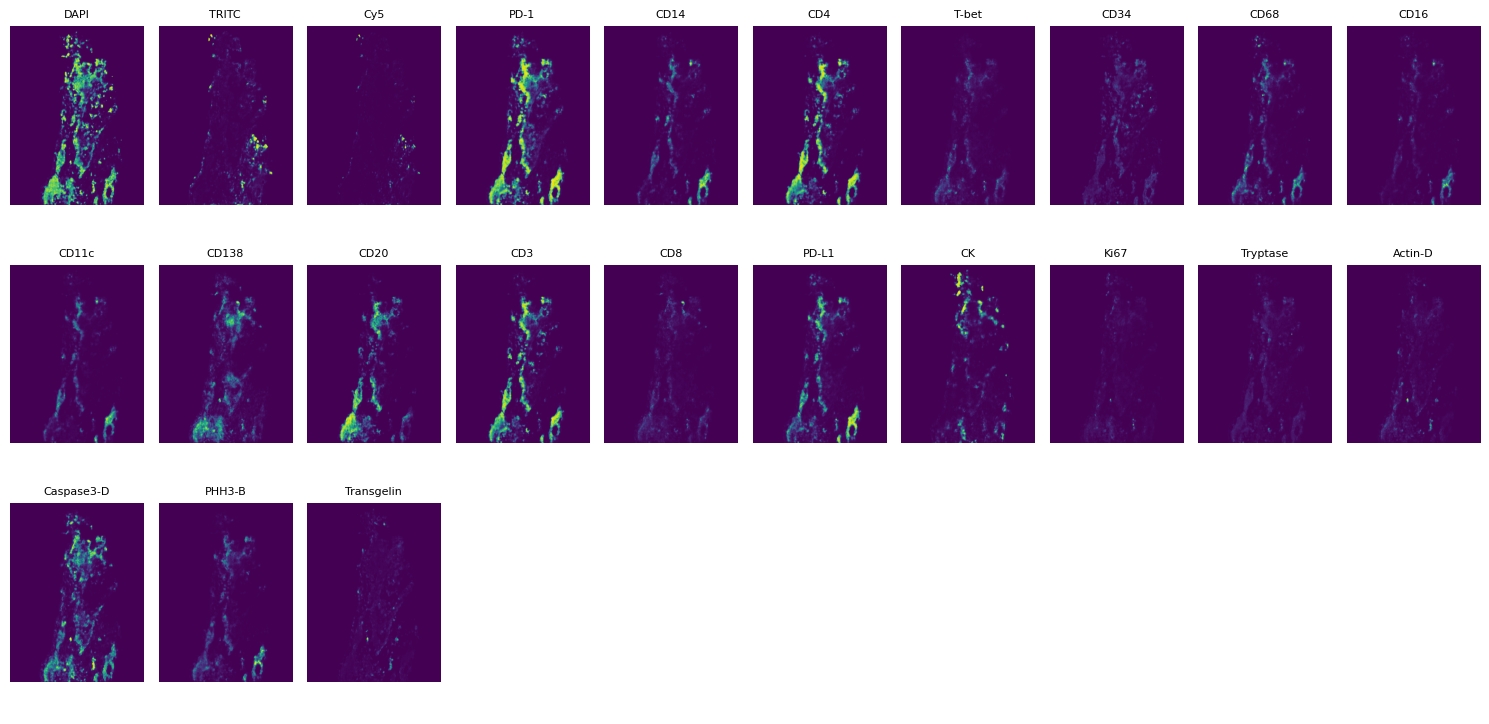

In [10]:
# Visualize all predicted biomarker channels in a grid layout
import matplotlib.pyplot as plt

# Create a 5x10 subplot grid to display all 50 biomarker channels
n_markers = wsi.images["gigatime_prediction"].data.shape[0]
n_cols = 10
n_rows = (n_markers + n_cols - 1) // n_cols  # Calculate number of rows needed
fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 2.5 * n_rows))
axs = axs.flatten()

# Plot each biomarker channel with its corresponding gene name as title
for i in range(n_markers):
    ax = axs[i]
    ax.imshow(wsi.images["gigatime_prediction"].data[i])
    ax.set_title(wsi.images["gigatime_prediction"].c.data[i], fontsize=8)
    ax.axis("off")

# Turn off any unused subplots
for j in range(i + 1, n_rows * n_cols):
    axs.flatten()[j].axis("off")

plt.tight_layout()
plt.show()

You can also use spatialdata plot to overlay specific biomarker channels on the original H&E image for better visualization. 

INFO     Rasterizing image for faster rendering.                                                                   


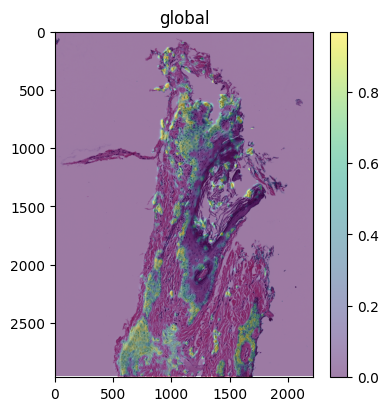

In [11]:
import spatialdata_plot  # noqa: F401

(
    wsi.pl.render_images("wsi_thumbnail")
    .pl.render_images("gigatime_prediction", channel=["DAPI"], alpha=0.5)
    .pl.show()
)

## Summary

Congratulations! You've successfully applied virtual staining to transform a standard H&E image into a rich, multiplexed dataset. This technique opens up numerous possibilities for:

- **Biomarker discovery**: Identify spatial patterns of gene expression without expensive assays
- **Digital pathology**: Enhance routine histological analysis with molecular insights
- **Research acceleration**: Generate hypotheses about tissue biology from existing slide archives
- **Cost-effective screening**: Prioritize samples for expensive molecular assays

The virtual staining approach represents a powerful bridge between traditional histopathology and modern molecular biology, enabling researchers to extract maximum value from standard histological preparations.